In [1]:
from enum import unique

import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from scipy.sparse import csr_matrix
from scipy.io import mmwrite
from pathlib import Path
import anndata
import copy
from scipy.io import mmread
from scipy.sparse import csr_matrix
import glob
import re
print("scanpy version:", sc.__version__)
print("numpy version:", np.__version__)

scanpy version: 1.11.5
numpy version: 2.3.0


C:\Users\admin\AppData\Local\Temp\ipykernel_32024\1465164428.py:18: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy version:", sc.__version__)


In [2]:
os.getcwd()

'D:\\lxk\\project\\lishan-20260613\\cellphoneDB'

In [3]:
os.chdir('D:\\lxk\\project\\lishan-20260613')
os.getcwd()
import helper.plot_helper as hp
hp.setMyStyle()

In [41]:
import h5py

with h5py.File("./h5ad/Endo_final.h5ad", "r+") as f:
    if "uns/log1p" in f:
        del f["uns/log1p"]
with h5py.File("./h5ad/Myeloid_final.h5ad", "r+") as f:
    if "uns/log1p" in f:
        del f["uns/log1p"]

In [60]:
CAT = sc.read_h5ad('./h5ad/Endo_final.h5ad')
CAMM = sc.read_h5ad('./h5ad/Myeloid_final.h5ad')
CAMM.obsm['X_umap'][:, 0] += 15

In [61]:
CAMM = CAMM[CAMM.obs['group'] == 'NP'].copy()

In [62]:
adata = anndata.concat([CAT,CAMM], join='outer', fill_value=0)

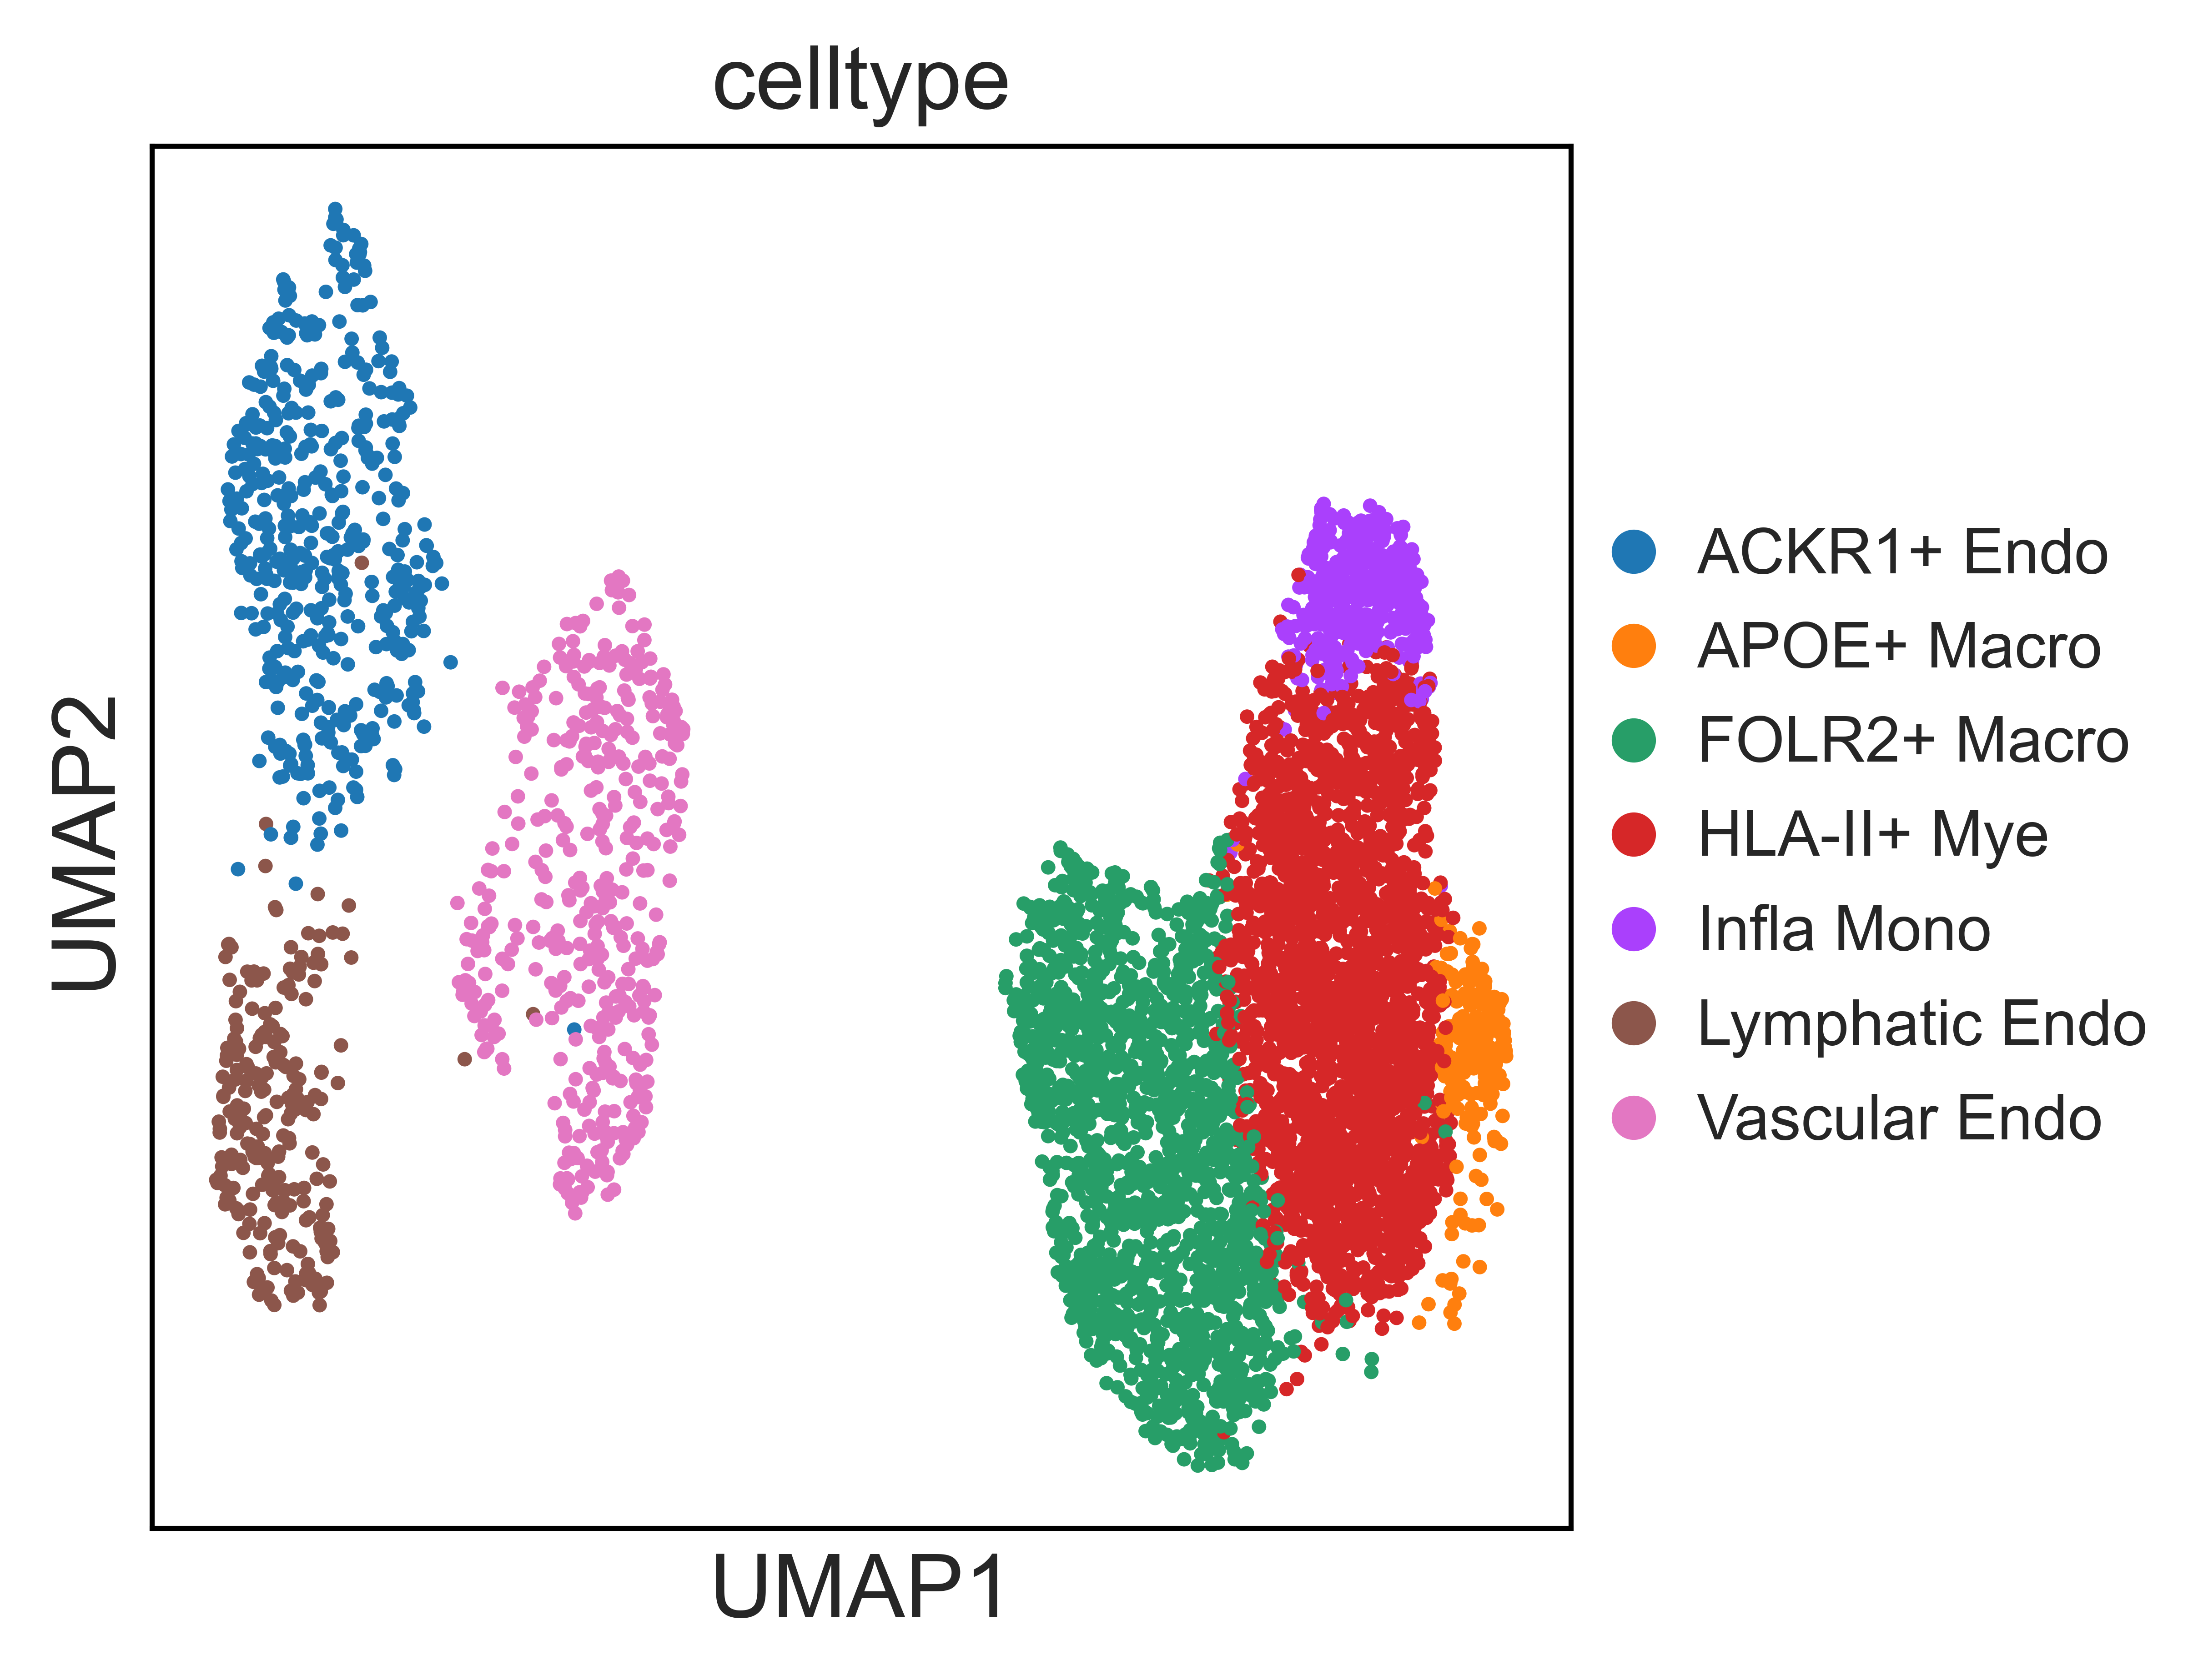

In [63]:

sc.pl.umap(adata,color='celltype',)

In [64]:
np.unique(adata.obs['celltype'])

array(['ACKR1+ Endo', 'APOE+ Macro', 'FOLR2+ Macro', 'HLA-II+ Mye',
       'Infla Mono', 'Lymphatic Endo', 'Vascular Endo'], dtype=object)

In [65]:
import omicverse as ov

#ov.plot_set(font_path='Arial')

In [66]:
cpdb_results, adata_cpdb = ov.single.run_cellphonedb_v5(
    adata,
    cpdb_file_path='./cellphoneDB/cellphonedb.zip',
    celltype_key='celltype',
    min_cell_fraction=0.005,
    min_genes=200,
    min_cells=3,
    iterations=1000,
    threshold=0.1,
    pvalue=0.05,
    threads=10,
    output_dir='./cpdb_results',
    cleanup_temp=True,
)

🔬 Starting CellPhoneDB analysis...
✅ Valid CellPhoneDB database found: ./cellphoneDB/cellphonedb.zip (0.1 MB)
   - Original data: 5690 cells, 26487 genes
   - Cell types passing 0.5% threshold: 7
   - Minimum cells required: 28
   - After filtering: 5690 cells, 26487 genes
   - After preprocessing: 5690 cells, 23817 genes
   - Temporary directory: C:\Users\admin\AppData\Local\Temp\cpdb_temp_lc0e1je2
   - Output directory: ./cpdb_results
   - Created temporary input files
   - Running CellPhoneDB statistical analysis...
Reading user files...
The following user files were loaded successfully:
C:\Users\admin\AppData\Local\Temp\cpdb_temp_lc0e1je2\counts_matrix.h5ad
C:\Users\admin\AppData\Local\Temp\cpdb_temp_lc0e1je2\metadata.tsv
[ ][CORE][30/06/26-07:10:33][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:42 Threads:10 Precision:3
[ ][CORE][30/06/26-07:10:33][WARNING] Debug random seed enabled. Set to 42
[ ][CORE][30/06/26-07:10:34][INFO] Running Real Analysis

100%|██████████| 1000/1000 [00:19<00:00, 50.23it/s]


[ ][CORE][30/06/26-07:10:54][INFO] Building Pvalues result
[ ][CORE][30/06/26-07:10:54][INFO] Building results
[ ][CORE][30/06/26-07:10:54][INFO] Scoring interactions: Filtering genes per cell type..


100%|██████████| 7/7 [00:00<00:00, 216.00it/s]

[ ][CORE][30/06/26-07:10:54][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|██████████| 7/7 [00:00<00:00, 499.99it/s]


[ ][CORE][30/06/26-07:10:54][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|██████████| 49/49 [00:07<00:00,  6.38it/s]


Saved deconvoluted to ./cpdb_results\statistical_analysis_deconvoluted_06_30_2026_071102.txt
Saved deconvoluted_percents to ./cpdb_results\statistical_analysis_deconvoluted_percents_06_30_2026_071102.txt
Saved means to ./cpdb_results\statistical_analysis_means_06_30_2026_071102.txt
Saved pvalues to ./cpdb_results\statistical_analysis_pvalues_06_30_2026_071102.txt
Saved significant_means to ./cpdb_results\statistical_analysis_significant_means_06_30_2026_071102.txt
Saved interaction_scores to ./cpdb_results\statistical_analysis_interaction_scores_06_30_2026_071102.txt
   - CellPhoneDB analysis completed successfully!
   - Formatting results for visualization...
   - Found 13 info columns and 49 cell type pairs
   - Found 134 pathway classifications
   - Created visualization AnnData: (49, 2117)
   - Cell interactions: 49
   - L-R pairs: 2117
   - Cleaned up temporary directory: C:\Users\admin\AppData\Local\Temp\cpdb_temp_lc0e1je2
✅ CellPhoneDB analysis pipeline completed!


In [49]:
adata.uns_keys()

['celltype_colors']

In [67]:

adata.obs['celltype'] = adata.obs['celltype'].astype('category')

if 'celltype_colors' not in adata.uns:
    fallback_colors = (
        ov.pl.red_color
        + ov.pl.blue_color
        + ov.pl.green_color
        + ov.pl.orange_color
        + ov.pl.purple_color
    )

    adata.uns['celltype_colors'] = fallback_colors[:len(adata.obs['celltype'].cat.categories)]

color_dict = dict(zip(
    adata.obs['celltype'].cat.categories,
    adata.uns['celltype_colors']
))

adata_plot = adata if 'cpdb_results' in adata.uns else adata_cpdb
comm_adata = ov.single.extract_comm_adata(adata, result_uns_key='cpdb_results') if 'cpdb_results' in adata.uns else adata_cpdb

focus_pathway = 'Signaling by Fibroblast growth factor'
focus_pair_lr = 'NCAM1_FGFR1'
focus_ligand = 'FN1'

umap_df = pd.DataFrame(
    adata.obsm['X_umap'][:, :2],
    columns=['x', 'y'],
    index=adata.obs_names,
)
umap_df['cell_type'] = adata.obs['celltype'].astype(str).values
node_positions = umap_df.groupby('cell_type', observed=True)[['x', 'y']].median()
embedding_points = umap_df.reset_index(drop=True)

comm_adata.uns['node_positions'] = node_positions
comm_adata.uns['embedding_points'] = embedding_points
comm_adata.uns['embedding_axes'] = ('UMAP_1', 'UMAP_2')

comparison_comm = comm_adata.copy()
comparison_comm.layers['means'] = np.asarray(comm_adata.layers['means']).copy() * 0.85
comparison_comm.layers['pvalues'] = np.clip(
    np.asarray(comm_adata.layers['pvalues']).copy() * 1.1,
    0.0,
    1.0,
)

adata_plot, comm_adata

(AnnData object with n_obs × n_vars = 49 × 2117
     obs: 'sender', 'receiver'
     var: 'id_cp_interaction', 'interacting_pair', 'partner_a', 'partner_b', 'gene_a', 'gene_b', 'secreted', 'receptor_a', 'receptor_b', 'annotation_strategy', 'is_integrin', 'directionality', 'classification', 'interaction_name'
     uns: 'node_positions', 'embedding_points', 'embedding_axes'
     layers: 'means', 'pvalues',
 AnnData object with n_obs × n_vars = 49 × 2117
     obs: 'sender', 'receiver'
     var: 'id_cp_interaction', 'interacting_pair', 'partner_a', 'partner_b', 'gene_a', 'gene_b', 'secreted', 'receptor_a', 'receptor_b', 'annotation_strategy', 'is_integrin', 'directionality', 'classification', 'interaction_name'
     uns: 'node_positions', 'embedding_points', 'embedding_axes'
     layers: 'means', 'pvalues')

In [68]:
figpath = hp.mydir('./fig/cellphone/NP[Endo_Myeloid]')

## 总通讯

In [69]:
%%capture
fig, ax = ov.pl.ccc_heatmap(
    adata_cpdb,
    plot_type='dot',
    display_by='aggregation',
    cmap='YlGnBu',

    show=False,
)

plt.savefig(f'{figpath}/总的通信.pdf', dpi=500, bbox_inches='tight')

## outgoing

In [70]:
%%capture
fig, ax = ov.pl.ccc_network_plot(
    comm_adata,
    plot_type='individual_outgoing',
    palette=color_dict,
    figsize=(20, 20),
    show=False,
)

plt.savefig(f'{figpath}/作为outgoing.pdf', dpi=500, bbox_inches='tight')

## 总的出度 入度

In [71]:
%%capture
fig, ax = ov.pl.ccc_stat_plot(
    adata_plot,
    plot_type='scatter',
    figsize=(6, 6),
    show=False,
)
plt.savefig(f'{figpath}/总的出度 入度.pdf', dpi=500, bbox_inches='tight')


## 分析通路

In [72]:
comm_adata.var['classification'] = comm_adata.var['classification'].fillna('')

In [57]:
print(np.unique(adata_plot.var['classification']).tolist())

['', 'Adhesion by CADM', 'Adhesion by CEAM', 'Adhesion by Cadherin', 'Adhesion by Collagen/Integrin', 'Adhesion by Desmosome', 'Adhesion by Fibronectin', 'Adhesion by GAP junction', 'Adhesion by ICAM', 'Adhesion by JAM', 'Adhesion by L1CAM', 'Adhesion by Laminin', 'Adhesion by Nectin', 'Adhesion by Osteopontin', 'Adhesion by Prothrombin', 'Adhesion by Thrombospondin', 'Adhesion by VCAM', 'Adhesion by Vitronectin', 'Adhesion by antigen THY1', 'Adhesion by tenascin', 'Cell adhesion by Phospholipase', 'Signaling by Acetylcholine', 'Signaling by Adenosine', 'Signaling by Adrenaline', 'Signaling by Adrenomedullin', 'Signaling by Agouti-related protein', 'Signaling by Agrin', 'Signaling by Amyloid-beta precursor protein', 'Signaling by Amyloid-like protein', 'Signaling by Angiopoietin', 'Signaling by Angiotensinogen', 'Signaling by Annexin', 'Signaling by Apelin', 'Signaling by Apolipoprotein', 'Signaling by Arachidonoylglycerol', 'Signaling by BMP', 'Signaling by Beta-nerve growth factor', 

In [73]:
focused_pathways = [
    "Signaling by Chemokines",
    "Signaling by Interleukin",
    "Signaling by Tumor necrosis factor",
    "Signaling by Complement",
    "Signaling by Interferon",

    "Signaling by Vascular endothelial growth factor",
    "Signaling by Placenta growth factor",
    "Signaling by Endothelin",

    "Signaling by Transforming growth factor",
    "Adhesion by Collagen/Integrin",
]

In [74]:
%%capture
for pathway in focused_pathways:

    try:
        tempdir = hp.mydir(f'{figpath}/{pathway}')
        fig, ax = ov.pl.ccc_stat_plot(
            adata_plot,
            plot_type='sankey',
            display_by='interaction',
            signaling=[pathway],
            palette=color_dict,
            top_n=10,
            figsize=(8, 6),
            show=False,
        )

        plt.savefig(f'{tempdir}/1.pdf', dpi=500, bbox_inches='tight')

        fig, ax = ov.pl.ccc_stat_plot(
            adata_plot,
            plot_type='bar',
            figsize=(6, 4),
            top_n=10,
            signaling = pathway,
            show=False,
        )
        plt.savefig(f'{tempdir}/2.pdf', dpi=500, bbox_inches='tight')

        fig, ax = ov.pl.ccc_stat_plot(
            adata_plot,
            plot_type='lr_contribution',
            signaling=pathway,
            figsize=(10, 5),
            show=False,
        )
        plt.savefig(f'{tempdir}/3.pdf', dpi=500, bbox_inches='tight')


        fig, ax = ov.pl.ccc_network_plot(
            comm_adata,
            plot_type='chord',
            signaling=pathway,
            palette=color_dict,
            normalize_to_sender=True,
            figsize=(6, 6),
            show=False,
        )
        plt.savefig(f'{tempdir}/4.pdf', dpi=500, bbox_inches='tight')



        fig, ax = ov.pl.ccc_network_plot(
            comm_adata,
            plot_type='embedding_network',
            signaling=pathway,
            node_positions=node_positions,
            embedding_points=embedding_points,
            palette=color_dict,
            top_n=20,
            figsize=(7, 10),
            show=False,
        )

        plt.savefig(f'{tempdir}/5.pdf', dpi=500, bbox_inches='tight')


        fig, ax = ov.pl.ccc_stat_plot(
            adata_plot,
            plot_type='scatter',
            signaling=pathway,
            figsize=(6, 6),
            show=False,
        )

        plt.savefig(f'{tempdir}/6.pdf', dpi=500, bbox_inches='tight')

        fig, ax = ov.pl.ccc_heatmap(
            adata_plot,
            plot_type='dot',
            sender_use=np.unique(adata.obs['celltype'].tolist()),
            display_by='interaction',
            signaling=pathway,
            top_n=10,
            transpose = True,
            cmap='viridis',
            figsize=(12, 7),
            #add_text = True,
            top_anno='cell',
            left_anno='cell',
            show=False,
        )

        plt.savefig(f'{tempdir}/7.pdf', dpi=500, bbox_inches='tight')

        fig, ax = ov.pl.ccc_heatmap(
            adata_plot,
            plot_type='dot',
            sender_use=np.unique(adata.obs['celltype'].tolist()),
            display_by='interaction',
            signaling=pathway,
            top_n=10,
            transpose = True,
            cmap='viridis',
            figsize=(12, 7),
            #add_text = True,
            top_anno='cell',
            left_anno='cell',
            show=False,
        )

        plt.savefig(f'{tempdir}/8.pdf', dpi=500, bbox_inches='tight')


    except ValueError:
        continue


In [ ]:
np.unique(adata.obs['celltype'])

In [ ]:

fig, ax = ov.pl.ccc_heatmap(
    adata_plot,
    plot_type='dot',
    sender_use=['IFN Mono', 'MAIT', 'TREM2+ DAMs', 'Tcm', 'Teff', 'Tem', 'Tex',
       'Tn', 'Trans Mono', 'Trm', 'cDC2', 'cMono', 'gdT'],
    display_by='interaction',
    signaling=['Signaling by HLA'],
    top_n=10,
    transpose = True,
    cmap='viridis',
    figsize=(12, 7),
    #add_text = True,
    top_anno='cell',
    left_anno='cell',


    show=False,

)
plt.savefig(f'{figpath}/test222222.pdf', dpi=500, bbox_inches='tight')

In [ ]:
adata_plot.var.columns

In [ ]:
adata_plot.var_names

In [ ]:
fig, ax = ov.pl.ccc_heatmap(
    adata_plot,
    plot_type='dot',
    sender_use=['Tn', 'Tcm', 'Teff'],
    display_by='aggregation',
    #signaling=['Adhesion by Cadherin'],
    top_n=5,
    cmap='viridis',
    figsize=(8, 3),
    show=False,
    show_row_names=True,
    show_col_names=True,

)

In [ ]:
fig, ax = ov.pl.ccc_heatmap(
    adata_plot,
    plot_type='focused_heatmap',
    signaling=['Adhesion by CADM'],
    min_interaction_threshold=0.1,
    display_by='interaction',
    cmap='YlGnBu',
    figsize=(7, 5),
    show=False,
    bottom_anno = 'cell'

)

In [ ]:
fig, ax = ov.pl.ccc_network_plot(
    adata_plot,
    plot_type='pathway',
    signaling=['Adhesion by CADM'],
    palette=color_dict,
    top_n=50,
    figsize=(6, 6),
    show=False,
)

In [ ]:
fig, ax = ov.pl.ccc_network_plot(
    comm_adata,
    plot_type='embedding_network',
    signaling=['Adhesion by Collagen/Integrin'],
    node_positions=node_positions,
    embedding_points=embedding_points,
    palette=color_dict,
    top_n=20,
    figsize=(8, 8),
    show=False,
)